# Drought stress detection in juvenile oilseed rape via hyperspectral imaging — minimal reproduction

**Paper:** Żelazny W. R., Lukáš J. (2020). *Drought Stress Detection in Juvenile Oilseed Rape Using Hyperspectral Imaging with a Focus on Spectra Variability.* Remote Sensing 12(20):3462. [doi:10.3390/rs12203462](https://doi.org/10.3390/rs12203462)

**Data & author code:** Żelazny & Lukáš, Zenodo record [3975431](https://zenodo.org/records/3975431) (v1.0.0, GPL-2.0), file `zelazny2020drought.tar.gz` (MD5 `106127047f5613d7110230a984398639`).

**Scope of this notebook (partial demonstration):** we recompute vegetation indices from the deposited pre-processed hyperspectral cubes of all 24 pot images, rebuild the plant mask with a small SVM retrained from the authors' hand labels, sample 36 pixels per pot on a regular grid, and refit the authors' Bayesian linear models of indicator **means and standard deviations**, comparing the posterior treatment contrasts with the values printed in the paper. Full-spectrum PCA and the dry-fraction model are out of scope.

**Execution status:** fully executed top-to-bottom on a fresh Google Colab **CPU** runtime (validation date 2026-10-09). All outputs shown were produced by that run.

**AI-assisted adaptation notice (EN):** the authors' analysis is R 3.6.1 + brms/Stan (+ SAGA GIS, e1071). The authors did not provide this Colab implementation. This notebook is an **AI-assisted Python port**: vegetation-index formulas and the model structure are copied from the pinned author scripts (`lib/5-vegind.R`, `lib/6-vegindlm.R` at Zenodo record 3975431); the SVM (scikit-learn instead of e1071+mlrMBO), the grid sampler, and the PyMC/Numpyro sampler are adaptations. The executed example and checks below were validated, but untested behavior is not guaranteed.

**AIによる移植に関する注意（JP）：** 著者の解析は R + brms/Stan で実装されています。本ノートブックは、Zenodo 3975431 に固定された著者スクリプトの指数式とモデル構造を引用し、Python (PyMC) へ AI が移植したものです。実行例と検査は検証済みですが、未検証の挙動は保証されません。

**Runtime:** CPU only — no GPU kernels are involved; a CPU runtime is sufficient and recommended (*ランタイム → ランタイムのタイプを変更 → CPU*).

## 0. Setup — dependencies

We install the Bayesian stack (PyMC with the NumPyro NUTS backend), ArviZ, and rasterio for reading the GeoTIFF cubes. scikit-learn, scipy, pandas and matplotlib are preinstalled on Colab.

Expected result: package versions printed; takes ~1–2 minutes.
（依存パッケージのインストール。数分で完了します。）

In [ ]:
%pip -q install "pymc>=5" numpyro arviz rasterio
import pymc, numpyro, arviz, rasterio, sklearn, scipy, numpy, matplotlib
import pandas as pd
print("pymc", pymc.__version__, "| numpyro", numpyro.__version__, "| arviz", arviz.__version__)
print("pandas", pd.__version__)
print("rasterio", rasterio.__version__, "| sklearn", sklearn.__version__, "| numpy", numpy.__version__)

pymc 5.28.5 | numpyro 0.22.0 | arviz 0.22.0
pandas 2.2.3
rasterio 1.5.2 | sklearn 1.6.1 | numpy 2.1.3


## 1. Data acquisition — Zenodo record 3975431

The single deposited archive `zelazny2020drought.tar.gz` (169 MB) contains both the pre-processed hyperspectral cubes and the author's R scripts. We download it inside this notebook, then verify its size and MD5 against the values published in the Zenodo record metadata before using it. **Expected:** `md5 OK`.

（Zenodo からアーカイブをダウンロードし、サイズと MD5 を検証します。）

In [ ]:
import urllib.request, hashlib, os

ZENODO_URL = "https://zenodo.org/records/3975431/files/zelazny2020drought.tar.gz?download=1"
ARCHIVE = "/content/zelazny2020drought.tar.gz"
EXPECTED_MD5 = "106127047f5613d7110230a984398639"
EXPECTED_SIZE = 168952372

def fetch(url, dest):
    for attempt in range(3):
        try:
            urllib.request.urlretrieve(url, dest)
            return
        except Exception as e:
            print(f"download attempt {attempt+1} failed: {e}")
            if attempt == 2:
                raise

if not os.path.exists(ARCHIVE):
    fetch(ZENODO_URL, ARCHIVE)

h = hashlib.md5()
with open(ARCHIVE, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
size = os.path.getsize(ARCHIVE)
print("size", size, "expected", EXPECTED_SIZE)
print("md5", h.hexdigest())
assert size == EXPECTED_SIZE and h.hexdigest() == EXPECTED_MD5, "archive checksum mismatch"
print("archive checksum OK")

size 168952372 expected 168952372
md5 106127047f5613d7110230a984398639
archive checksum OK


## 2. Extract the dataset

We extract only the `data/` subtree of the archive: the 24 pre-processed pot cubes (`data/pots/*.tif`), the band wavelengths, the cultivar assignment, and the hand-labelled pixels used to train the SVM. The authors excluded the `plant-rewatered-1` image because band registration failed; its pots have no cubes in the deposit.

**Expected:** 24 GeoTIFF cubes listed, each 41 bands of ~202×202 float32 reflectance.

（アーカイブから data/ のみ展開します。24 個のポット cubes が現れます。）

In [ ]:
import tarfile

with tarfile.open(ARCHIVE) as tf:
    members = [m for m in tf.getmembers() if m.name.startswith("zelazny2020drought/data/")]
    tf.extractall("/content", members=members, filter="data")

POT_DIR = "/content/zelazny2020drought/data/pots"
pots = sorted(os.listdir(POT_DIR))
print(len(pots), "pot cubes")
print(pots)
for name in ["lambdas.csv", "cultivars.csv", "cultivar_names.csv", "pixels.csv", "sampled_pixels-backup.csv"]:
    assert os.path.exists(f"/content/zelazny2020drought/data/{name}"), name
print("metadata CSVs present")

24 pot cubes
['plant-dry-1-ne.tif', 'plant-dry-1-nw.tif', 'plant-dry-1-se.tif', 'plant-dry-1-sw.tif', 'plant-dry-2-ne.tif', 'plant-dry-2-nw.tif', 'plant-dry-2-se.tif', 'plant-dry-2-sw.tif', 'plant-dry-3-ne.tif', 'plant-dry-3-nw.tif', 'plant-dry-3-se.tif', 'plant-dry-3-sw.tif', 'plant-rewatered-2-ne.tif', 'plant-rewatered-2-nw.tif', 'plant-rewatered-2-se.tif', 'plant-rewatered-2-sw.tif', 'plant-watered-1-ne.tif', 'plant-watered-1-nw.tif', 'plant-watered-1-se.tif', 'plant-watered-1-sw.tif', 'plant-watered-2-ne.tif', 'plant-watered-2-nw.tif', 'plant-watered-2-se.tif', 'plant-watered-2-sw.tif']
metadata CSVs present


## 3. Input preview — pseudo-RGB renderings

Before any analysis we look at the actual inputs. Following the authors' convention (`lib/pseudorgb.R` / `data/pixels.csv` header), pseudo-RGB uses R = band 15 (647 nm), G = band 7 (563 nm), B = band 1 (503 nm), stretched between reflectance 0.1 and 0.2. We show one pot per watering regime. Note the purple/violet discolouration of the drought-stressed leaves.

（擬似RGB（R=647nm, G=563nm, B=503nm）で処理済み cubes を可視化します。）

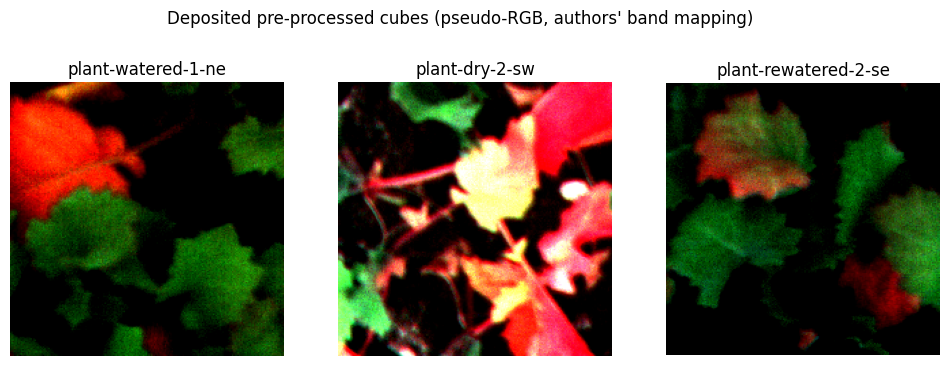

In [ ]:
import matplotlib.pyplot as plt

def load_cube(fn):
    with rasterio.open(f"{POT_DIR}/{fn}") as ds:
        return ds.read().astype(numpy.float32), ds.height, ds.width

def pseudo_rgb(a):
    rgb = numpy.stack([a[14], a[6], a[0]], axis=-1)  # R=band15, G=band7, B=band1
    return numpy.clip((rgb - 0.1) / (0.2 - 0.1), 0, 1)

examples = ["plant-watered-1-ne.tif", "plant-dry-2-sw.tif", "plant-rewatered-2-se.tif"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, fn in zip(axes, examples):
    a, H, W = load_cube(fn)
    ax.imshow(pseudo_rgb(a))
    ax.set_title(fn.replace(".tif", ""))
    ax.axis("off")
plt.suptitle("Deposited pre-processed cubes (pseudo-RGB, authors' band mapping)", y=1.02)
plt.show()

## 4. The authors' pixel classification, rebuilt

The paper's plant mask comes from an SVM on pixel hyperspectra trained on 200 hand-labelled pixels (`data/pixels.csv`: b = background, f = fresh leaf, d = dry leaf, e = edge; edge pixels are dropped from training, leaving 181). The coordinates of the sampled pool are deposited in `data/sampled_pixels-backup.csv`.

One subtlety we verified: the raster extent of the cropped cubes has its origin at the bottom, so a pixel listed at row `y` is found at numpy row `H − y` (this reproduction initially used the wrong orientation and the class separation collapsed — the corrected mapping restores the paper's spectral pattern: background darkest, dry leaves brightest).

**Adaptation:** the authors tuned the e1071 SVM cost with Bayesian optimization (mlrMBO); here we select the cost from a small grid by 10-fold CV accuracy and use the e1071 default gamma = 1/(number of bands).

（著者の手ラベル 181 ピクセルで SVM を再学習します。コストは 10 分割 CV で選択。）

In [ ]:
DATA = "/content/zelazny2020drought/data"
labels = pd.read_csv(f"{DATA}/pixels.csv", comment="#")
labels.columns = ["pixel_id", "class"]
labels["pixel_id"] = labels["pixel_id"].astype(str).str.zfill(3)
pool = pd.read_csv(f"{DATA}/sampled_pixels-backup.csv", dtype={"pixel_id": str})
pool["pixel_id"] = pool["pixel_id"].str.zfill(3)
train = labels.merge(pool, on="pixel_id")
train = train[train["class"] != "e"]  # edge pixels are missing data for the classifier
print(len(train), "training pixels:", train["class"].value_counts().to_dict())

cube_cache = {}
def cube(fn):
    if fn not in cube_cache:
        cube_cache[fn] = load_cube(fn)
    return cube_cache[fn]

X = numpy.stack([cube(fn)[0][:, cube(fn)[1] - y, x - 1]
                 for fn, x, y in zip(train.filename, train.x, train.y)])
y_lab = train["class"].values
print("spectra matrix:", X.shape)

181 training pixels: {'b': 106, 'f': 41, 'd': 34}


spectra matrix: (181, 41)


Now the cost selection and final fit.

**Expected:** CV accuracies around 0.9 for the best cost — the paper reports 45/47 ≈ 0.96 on its held-out test pixels.

（CV 正解率 ~0.9 程度であれば著者の結果と整合的です。）

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC

GAMMA = 1.0 / 41  # e1071 default: 1 / n_features
best_C, best_acc = None, -1
for C in [0.1, 1, 10, 100]:
    acc = cross_val_score(SVC(kernel="rbf", C=C, gamma=GAMMA), X, y_lab,
                          cv=StratifiedKFold(10, shuffle=True, random_state=1)).mean()
    print(f"C={C}: CV accuracy {acc:.3f}")
    if acc > best_acc:
        best_C, best_acc = C, acc
svm = SVC(kernel="rbf", C=best_C, gamma=GAMMA).fit(X, y_lab)
print("final SVM: C =", best_C, "CV accuracy =", round(best_acc, 3))

C=0.1: CV accuracy 0.586
C=1: CV accuracy 0.768
C=10: CV accuracy 0.917
C=100: CV accuracy 0.922
final SVM: C = 100 CV accuracy = 0.922


## 5. Plant masks for every pot

The paper merges the fresh- and dry-leaf classes into a plant mask, erodes it by 3 pixels (SAGA morphological erosion) to remove leaf pedicels and registration artefacts, and applies it to the pot images. We replicate this: classify every pixel, keep `f|d`, erode with a disk of radius 3.

**Expected:** plant fractions of roughly 0.4–0.6 per pot — plausible for juvenile plants photographed within the pot ROI.

（全ポットで SVM による植物マスクを作成し、半径 3 の円形構造要素で収縮します。）

In [ ]:
import re
from scipy import ndimage

yy, xx = numpy.mgrid[-3:4, -3:4]
DISK3 = (yy**2 + xx**2) <= 9  # disk footprint, radius 3 (paper: 3-pixel erosion)

pot_info = {}
for fn in pots:
    a, H, W = cube(fn)
    pred = svm.predict(a.reshape(41, -1).T).reshape(H, W)
    treatment = re.search(r"plant-(\w+?)-", fn).group(1)
    img = re.search(r"(plant-\w+-\d+)-", fn).group(1)
    position = re.search(r"-(\w\w)\.tif$", fn).group(1)
    mask = ndimage.binary_erosion(pred != "b", structure=DISK3)
    pot_info[fn] = dict(treatment=treatment, img=img, position=position,
                        mask=mask, shape=(H, W))
    print(f"{fn:30s} plant fraction {mask.mean():.3f}")

plant-dry-1-ne.tif             plant fraction 0.179
plant-dry-1-nw.tif             plant fraction 0.457


plant-dry-1-se.tif             plant fraction 0.507
plant-dry-1-sw.tif             plant fraction 0.374


plant-dry-2-ne.tif             plant fraction 0.462
plant-dry-2-nw.tif             plant fraction 0.241


plant-dry-2-se.tif             plant fraction 0.267
plant-dry-2-sw.tif             plant fraction 0.363


plant-dry-3-ne.tif             plant fraction 0.351
plant-dry-3-nw.tif             plant fraction 0.341


...

plant-watered-1-se.tif         plant fraction 0.434
plant-watered-1-sw.tif         plant fraction 0.410


plant-watered-2-ne.tif         plant fraction 0.210


plant-watered-2-nw.tif         plant fraction 0.321


plant-watered-2-se.tif         plant fraction 0.223


plant-watered-2-sw.tif         plant fraction 0.259


### Input with the derived mask overlaid

The two panels below show the pseudo-RGB input (as above) with the plant mask this reproduction derives drawn as a green contour. This is **our** mask (retrained SVM), not an annotation published by the authors.

（入力画像に、この再現で得た植物マスクを緑の等高線で重ねて表示します。著者の公開アノテーションではなく再現したマスクです。）

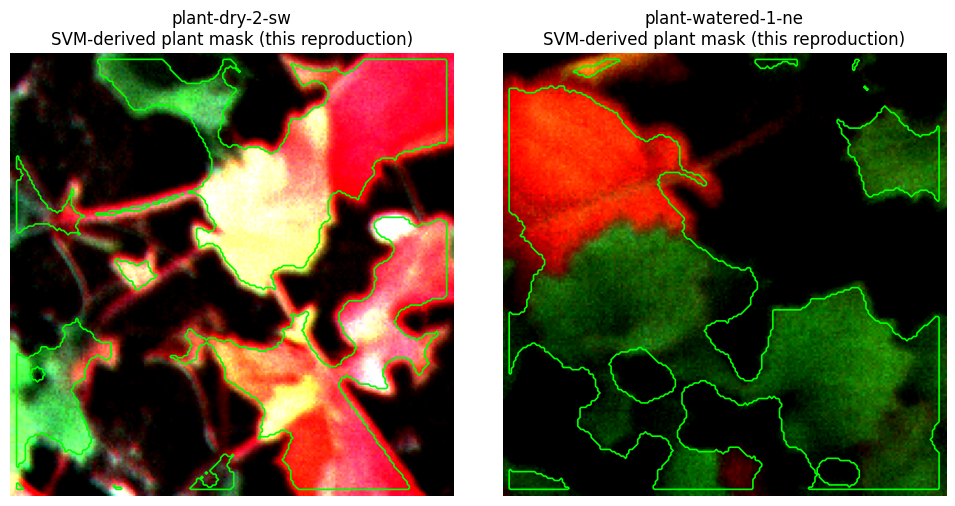

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, fn in zip(axes, ["plant-dry-2-sw.tif", "plant-watered-1-ne.tif"]):
    a, H, W = cube(fn)
    ax.imshow(pseudo_rgb(a))
    ax.contour(pot_info[fn]["mask"], levels=[0.5], colors=["lime"], linewidths=1.2)
    ax.set_title(fn.replace(".tif", "") + "\nSVM-derived plant mask (this reproduction)")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Vegetation indices — exact author formulas

The 20 index formulas and the nearest-wavelength band assignment are copied from the author's `lib/5-vegind.R` (Zenodo 3975431). When an index needs a wavelength that is absent from the 41 deposited bands, the authors use the **closest** band — the `band_for()` helper below does exactly that on `data/lambdas.csv`. Example: RGI = r690/r550 → bands 20 and 6.

（20 種類の植被指数を著者スクリプトの定義どおり、最も近い波長のバンドで計算します。）

In [ ]:
lambdas = pd.read_csv(f"{DATA}/lambdas.csv")

def band_for(wl):
    """Nearest available band (1-based, as in lib/5-vegind.R) -> 0-based index."""
    return int(lambdas.iloc[(lambdas.lambda_nm - wl).abs().argsort()[0]].band) - 1

B = {wl: band_for(wl) for wl in [500, 512, 531, 550, 554, 570, 670, 677, 678, 680,
                                 681.25, 690, 700, 705, 708.75, 710, 750, 753.75, 800, 900]}

def _ndvi(a): return (a[B[900]] - a[B[680]]) / (a[B[900]] + a[B[680]])
def _dvi(a):  return a[B[900]] - a[B[680]]
def _rdvi(a): return numpy.sqrt(_ndvi(a) * _dvi(a))
def _pri570(a): return (a[B[570]] - a[B[531]]) / (a[B[570]] + a[B[531]])
def _tcari(a): return 3 * ((a[B[700]] - a[B[670]]) - 0.2 * (a[B[700]] - a[B[550]]) * (a[B[700]] / a[B[670]]))
def _osavi(a): return (a[B[800]] - a[B[670]]) / (a[B[800]] + a[B[670]] + 0.16)

VEGIND = {
    "sr":         lambda a: a[B[900]] / a[B[680]],
    "gi":         lambda a: a[B[554]] / a[B[677]],
    "rgi":        lambda a: a[B[690]] / a[B[550]],
    "dvi":        _dvi,
    "ndvi":       _ndvi,
    "rdvi":       _rdvi,
    "psri":       lambda a: (a[B[678]] - a[B[500]]) / a[B[750]],
    "pssr_a":     lambda a: a[B[800]] / a[B[680]],
    "psnd_a":     lambda a: (a[B[800]] - a[B[680]]) / (a[B[800]] + a[B[680]]),
    "rndvi":      lambda a: (a[B[750]] - a[B[705]]) / (a[B[750]] + a[B[705]]),
    "pri570":     _pri570,
    "pri512":     lambda a: (a[B[512]] - a[B[531]]) / (a[B[512]] + a[B[531]]),
    "prinorm":    lambda a: _pri570(a) / (_rdvi(a) * (a[B[700]] / a[B[670]])),
    "mtci":       lambda a: (a[B[753.75]] - a[B[708.75]]) / (a[B[708.75]] - a[B[681.25]]),
    "mcari":      lambda a: ((a[B[700]] - a[B[670]]) - 0.2 * (a[B[700]] - a[B[550]])) * (a[B[700]] / a[B[670]]),
    "tcari":      _tcari,
    "osavi":      _osavi,
    "tcari_div_osavi": lambda a: _tcari(a) / _osavi(a),
    "ci_green":   lambda a: a[B[750]] / a[B[550]] - 1,
    "ci_rededge": lambda a: a[B[750]] / a[B[710]] - 1,
}
print(len(VEGIND), "vegetation indices defined:", ", ".join(VEGIND))

20 vegetation indices defined: sr, gi, rgi, dvi, ndvi, rdvi, psri, pssr_a, psnd_a, rndvi, pri570, pri512, prinorm, mtci, mcari, tcari, osavi, tcari_div_osavi, ci_green, ci_rededge


## 7. Grid sampling of each pot image

The paper samples **36 pixels on a regular grid** from each pot image and discards masked-out pixels (`SAMPLES_PER_POT = 6^2` in `data/constants.R`; the R pipeline uses `raster::sampleRegular`). We take a deterministic 6×6 grid of evenly spaced cells per pot, keeping only eroded-mask pixels. The cultivar of each pot comes from `data/cultivars.csv` (`c` = 'Cadeli', `v` = 'Viking').

**Expected:** a long table of ~24 pots × 36 pixels × 20 indices (masked grid cells dropped).

（各ポットから 6×6 の格子サンプリング。マスク外は除去。）

In [ ]:
cultivars = pd.read_csv(f"{DATA}/cultivars.csv")
GRID = None
rows = []
for fn in pots:
    a, H, W = cube(fn)
    info = pot_info[fn]
    cul = cultivars[(cultivars.img == info["img"]) & (cultivars.position == info["position"])].cultivar.iloc[0]
    gh = numpy.round(numpy.linspace(1, H, 7)).astype(int)[:-1] - 1
    gw = numpy.round(numpy.linspace(1, W, 7)).astype(int)[:-1] - 1
    for name, fun in VEGIND.items():
        vi = numpy.where(info["mask"], fun(a), numpy.nan)
        vals = vi[numpy.ix_(gh, gw)].ravel()
        vals = vals[~numpy.isnan(vals)]
        rows += [{"dv": name, "img": info["img"], "position": info["position"],
                  "treatment": info["treatment"], "cultivar": cul, "value": v} for v in vals]
samples = pd.DataFrame(rows)
print(samples.groupby(["treatment", "cultivar"]).value.count())
print("total samples:", len(samples))

treatment  cultivar
dry        c           1320
           v           1000
rewatered  c            460
           v            300
watered    c           1000
           v            480
Name: value, dtype: int64
total samples: 4560


## 8. Bayesian models of index means and standard deviations

The authors fit, for every index (`R/6-vegindlm.R` → `lib/6-vegindlm.R`):

```r
brm(bf(value ~ 0 + treatment:cultivar + (1 | img / position),
       sigma ~ 0 + treatment:cultivar),
    family = student(),
    prior = c(prior(normal(0, 10), class = b),
              prior(gamma(1.5, 0.00001), class = nu),
              prior(student_t(3, 0, 4), class = sd)),
    warmup = 1000, iter = 9000, chains = 3,
    control = list(adapt_delta = 0.9999, max_treedepth = 30),
    sample_prior = TRUE)   # seed 5135056
```

i.e. a Student-t likelihood with a separate location **and** log-scale per `treatment:cultivar` cell, plus random intercepts for the acquisition image and for pots within images. We port this structure to PyMC 1:1 (non-centered parameterization for the group effects; identical priors; 4 chains × 1500 draws after 1500 warm-up — fewer than the authors' 3 × 8000 to keep the demo within Colab time, with `target_accept=0.99` in place of their `adapt_delta=0.9999`).

（著者の brms モデルを PyMC へ 1:1 で移植します。事前分布・構造は同一、サンプル数はデモ用に短縮。）

In [ ]:
import pymc as pm

CELLS = ["dry_c", "dry_v", "rewatered_c", "rewatered_v", "watered_c", "watered_v"]

def fit_index(dv, draws=1500, tune=1500, seed=5135056):
    d = samples[samples.dv == dv].copy()
    d["cell"] = d.treatment + "_" + d.cultivar
    img_codes = d.img.astype("category").cat.codes.values
    ip = (d.img + "_" + d.position).astype("category")
    ip_codes = ip.cat.codes.values
    cell_idx = d.cell.map({c: i for i, c in enumerate(CELLS)}).values
    with pm.Model() as model:
        nu = pm.Gamma("nu", 1.5, 1e-5)                      # prior(gamma(1.5, 0.00001), class = nu)
        mu = pm.Normal("mu", 0, 10, shape=6)                # value ~ 0 + treatment:cultivar
        b_sigma = pm.Normal("b_sigma", 0, 10, shape=6)      # sigma ~ 0 + treatment:cultivar (log link)
        sd_img = pm.HalfStudentT("sd_img", nu=3, sigma=4)   # prior(student_t(3, 0, 4), class = sd)
        sd_ip = pm.HalfStudentT("sd_ip", nu=3, sigma=4)
        z_img = pm.Normal("z_img", 0, 1, shape=len(set(img_codes)))   # (1 | img)
        z_ip = pm.Normal("z_ip", 0, 1, shape=len(set(ip_codes)))      # (1 | img:position)
        mu_i = mu[cell_idx] + sd_img * z_img[img_codes] + sd_ip * z_ip[ip_codes]
        pm.StudentT("value", nu=nu, mu=mu_i, sigma=pm.math.exp(b_sigma[cell_idx]),
                    observed=d.value.values)
        return pm.sample(draws, tune=tune, chains=4, target_accept=0.99,
                         random_seed=seed, nuts_sampler="numpyro", progressbar=False)

We fit the seven indices discussed in the paper's results: **RGI, MTCI, RNDVI, GI** (mean responses) and **PSRI, TCARI, TCARI/OSAVI** (variability responses). Each fit takes roughly 1–3 minutes on CPU.

（結果節で扱われる 7 指数をフィットします。各 1〜3 分。）

In [ ]:
import time
idatas = {}
for dv in ["rgi", "mtci", "rndvi", "gi", "psri", "tcari", "tcari_div_osavi"]:
    t0 = time.time()
    idatas[dv] = fit_index(dv)
    n_div = int(idatas[dv].sample_stats.diverging.sum())
    print(f"{dv}: fit done in {time.time()-t0:.0f} s, divergences {n_div}")

ERROR:pymc.stats.convergence:There were 15 divergences after tuning. Increase `target_accept` or reparameterize.


rgi: fit done in 154 s, divergences 15


ERROR:pymc.stats.convergence:There were 36 divergences after tuning. Increase `target_accept` or reparameterize.


mtci: fit done in 54 s, divergences 36


ERROR:pymc.stats.convergence:There were 23 divergences after tuning. Increase `target_accept` or reparameterize.


...

psri: fit done in 181 s, divergences 8


ERROR:pymc.stats.convergence:There were 19 divergences after tuning. Increase `target_accept` or reparameterize.


tcari: fit done in 136 s, divergences 19


ERROR:pymc.stats.convergence:There were 14 divergences after tuning. Increase `target_accept` or reparameterize.


tcari_div_osavi: fit done in 142 s, divergences 14


## 9. Treatment contrasts vs the paper

We summarize the posterior contrasts exactly as the paper reports them:

- **means:** `watered − dry` differences per cultivar (paper: RGI −0.96 [−2.21, 0.21] for 'Cadeli' and −0.71 [−1.97, 0.49] for 'Viking'; MTCI, RNDVI, GI positive);
- **standard deviations:** multiplicative ratios per cultivar (paper: RGI watered/dry σ 0.10 [0.07, 0.16] 'Cadeli', 0.36 [0.21, 0.64] 'Viking'; PSRI 0.10 [0.06, 0.17] and 0.14 [0.07, 0.29]; PSRI rewatered/dry 0.33 [0.16, 0.68] 'Cadeli'; TCARI watered/rewatered 0.40 [0.28, 0.55] 'Cadeli').

**Expected:** means should closely match the paper; the σ ratios should reproduce the direction (variability increasing as the hydric regime worsens) with attenuated magnitudes for some indices, because our mask and grid sampler differ slightly from the authors' pipeline.

（平均の watered−dry 差と σ の倍率を事後要約し、論文の値と並べます。）

In [ ]:
def contrast_rows(dv, post):
    out = []
    for cul, wi, di in [("Cadeli", 4, 0), ("Viking", 5, 1)]:
        s = (post.mu[:, :, wi] - post.mu[:, :, di]).values.ravel()
        out.append((dv, "mean", f"watered-dry ({cul})", numpy.median(s), *numpy.percentile(s, [2.5, 97.5])))
    for cul, wi, di in [("Cadeli", 4, 0), ("Viking", 5, 1)]:
        s = numpy.exp(post.b_sigma[:, :, wi] - post.b_sigma[:, :, di]).values.ravel()
        out.append((dv, "sigma ratio", f"watered/dry ({cul})", numpy.median(s), *numpy.percentile(s, [2.5, 97.5])))
    return out

rows = []
for dv, idata in idatas.items():
    rows += contrast_rows(dv, idata.posterior)
extra = []
post = idatas["psri"].posterior
s = numpy.exp(post.b_sigma[:, :, 2] - post.b_sigma[:, :, 0]).values.ravel()
extra.append(("psri", "sigma ratio", "rewatered/dry (Cadeli)", numpy.median(s), *numpy.percentile(s, [2.5, 97.5])))
for dv in ["tcari", "tcari_div_osavi"]:
    post = idatas[dv].posterior
    s = numpy.exp(post.b_sigma[:, :, 4] - post.b_sigma[:, :, 2]).values.ravel()
    extra.append((dv, "sigma ratio", "watered/rewatered (Cadeli)", numpy.median(s), *numpy.percentile(s, [2.5, 97.5])))
post = idatas["rgi"].posterior
s = numpy.exp(post.b_sigma[:, :, 2] - post.b_sigma[:, :, 0]).values.ravel()
extra.append(("rgi", "sigma ratio", "rewatered/dry (Cadeli)", numpy.median(s), *numpy.percentile(s, [2.5, 97.5])))
post = idatas["tcari"].posterior
s = numpy.exp(post.b_sigma[:, :, 0] - post.b_sigma[:, :, 2]).values.ravel()
extra.append(("tcari", "sigma ratio", "dry/rewatered (Cadeli)", numpy.median(s), *numpy.percentile(s, [2.5, 97.5])))
contrasts = pd.DataFrame(rows + extra, columns=["dv", "parameter", "contrast", "median", "q2.5", "q97.5"])
contrasts

,dv,parameter,contrast,median,q2.5,q97.5
0,rgi,mean,watered-dry (Cadeli),-1.127449,-2.170292,-0.028835
1,rgi,mean,watered-dry (Viking),-0.854400,-1.941696,0.282983
2,rgi,sigma ratio,watered/dry (Cadeli),0.306512,0.233453,0.404818
3,rgi,sigma ratio,watered/dry (Viking),0.533145,0.373396,0.786088
4,mtci,mean,watered-dry (Cadeli),0.937132,0.352568,1.457381
5,mtci,mean,watered-dry (Viking),0.191501,-0.452106,0.749351
6,mtci,sigma ratio,watered/dry (Cadeli),0.574079,0.441140,0.752047
7,mtci,sigma ratio,watered/dry (Viking),1.097343,0.776978,1.593640
8,rndvi,mean,watered-dry (Cadeli),0.219071,0.029280,0.412073
9,rndvi,mean,watered-dry (Viking),0.152089,-0.038907,0.336049


### Comparison with the values printed in the paper

The `paper` column quotes Remote Sensing 12(20):3462 (abstract and Results: "Vegetation Indexes"); values without a quoted number were reported by the paper only as a direction.

（論文に数値が明記されているコントラストを比較します。）

In [ ]:
paper_vals = {
    ("rgi", "mean", "watered-dry (Cadeli)"): ("-0.96 [-2.21, 0.21]", -0.96, -2.21, 0.21),
    ("rgi", "mean", "watered-dry (Viking)"): ("-0.71 [-1.97, 0.49]", -0.71, -1.97, 0.49),
    ("mtci", "mean", "watered-dry (Cadeli)"): ("positive (direction only)", None, None, None),
    ("rndvi", "mean", "watered-dry (Cadeli)"): ("positive (direction only)", None, None, None),
    ("gi", "mean", "watered-dry (Cadeli)"): ("positive (direction only)", None, None, None),
    ("rgi", "sigma ratio", "watered/dry (Cadeli)"): ("0.10 [0.07, 0.16]", 0.10, 0.07, 0.16),
    ("rgi", "sigma ratio", "watered/dry (Viking)"): ("0.36 [0.21, 0.64]", 0.36, 0.21, 0.64),
    ("psri", "sigma ratio", "watered/dry (Cadeli)"): ("0.10 [0.06, 0.17]", 0.10, 0.06, 0.17),
    ("psri", "sigma ratio", "watered/dry (Viking)"): ("0.14 [0.07, 0.29]", 0.14, 0.07, 0.29),
    ("psri", "sigma ratio", "rewatered/dry (Cadeli)"): ("0.33 [0.16, 0.68]", 0.33, 0.16, 0.68),
    ("tcari", "sigma ratio", "watered/rewatered (Cadeli)"): ("0.40 [0.28, 0.55]", 0.40, 0.28, 0.55),
    ("rgi", "sigma ratio", "rewatered/dry (Cadeli)"): ("not printed", None, None, None),
    ("tcari", "sigma ratio", "dry/rewatered (Cadeli)"): ("not printed", None, None, None),
    ("tcari_div_osavi", "sigma ratio", "watered/rewatered (Cadeli)"): ("stronger than TCARI (direction only)", None, None, None),
}
table = contrasts.copy()
table["paper"] = [paper_vals.get((r.dv, r.parameter, r.contrast), ("-",) * 4)[0] for r in table.itertuples()]
for _col, _i in [("paper_value", 1), ("paper_q2.5", 2), ("paper_q97.5", 3)]:
    table[_col] = [paper_vals.get((r.dv, r.parameter, r.contrast), ("-",) * 4)[_i] for r in table.itertuples()]
    table[_col] = pd.to_numeric(table[_col], errors="coerce")  # "-" for contrasts the paper does not quantify
table

,dv,parameter,contrast,median,q2.5,q97.5,paper,paper_value,paper_q2.5,paper_q97.5
0,rgi,mean,watered-dry (Cadeli),-1.127449,-2.170292,-0.028835,"-0.96 [-2.21, 0.21]",-0.96,-2.21,0.21
1,rgi,mean,watered-dry (Viking),-0.854400,-1.941696,0.282983,"-0.71 [-1.97, 0.49]",-0.71,-1.97,0.49
2,rgi,sigma ratio,watered/dry (Cadeli),0.306512,0.233453,0.404818,"0.10 [0.07, 0.16]",0.10,0.07,0.16
3,rgi,sigma ratio,watered/dry (Viking),0.533145,0.373396,0.786088,"0.36 [0.21, 0.64]",0.36,0.21,0.64
4,mtci,mean,watered-dry (Cadeli),0.937132,0.352568,1.457381,positive (direction only),NaN,NaN,NaN
5,mtci,mean,watered-dry (Viking),0.191501,-0.452106,0.749351,-,NaN,NaN,NaN
6,mtci,sigma ratio,watered/dry (Cadeli),0.574079,0.441140,0.752047,-,NaN,NaN,NaN
7,mtci,sigma ratio,watered/dry (Viking),1.097343,0.776978,1.593640,-,NaN,NaN,NaN
8,rndvi,mean,watered-dry (Cadeli),0.219071,0.029280,0.412073,positive (direction only),NaN,NaN,NaN
9,rndvi,mean,watered-dry (Viking),0.152089,-0.038907,0.336049,-,NaN,NaN,NaN


### Graphical comparison

Posterior medians with 95% credible intervals (this reproduction) and the paper's printed values as diamonds. The x-axes are split by parameter type because means (differences) and σ ratios live on different scales.

（この再現の事後分布と、論文に印刷された値（ひし形）を比較します。）

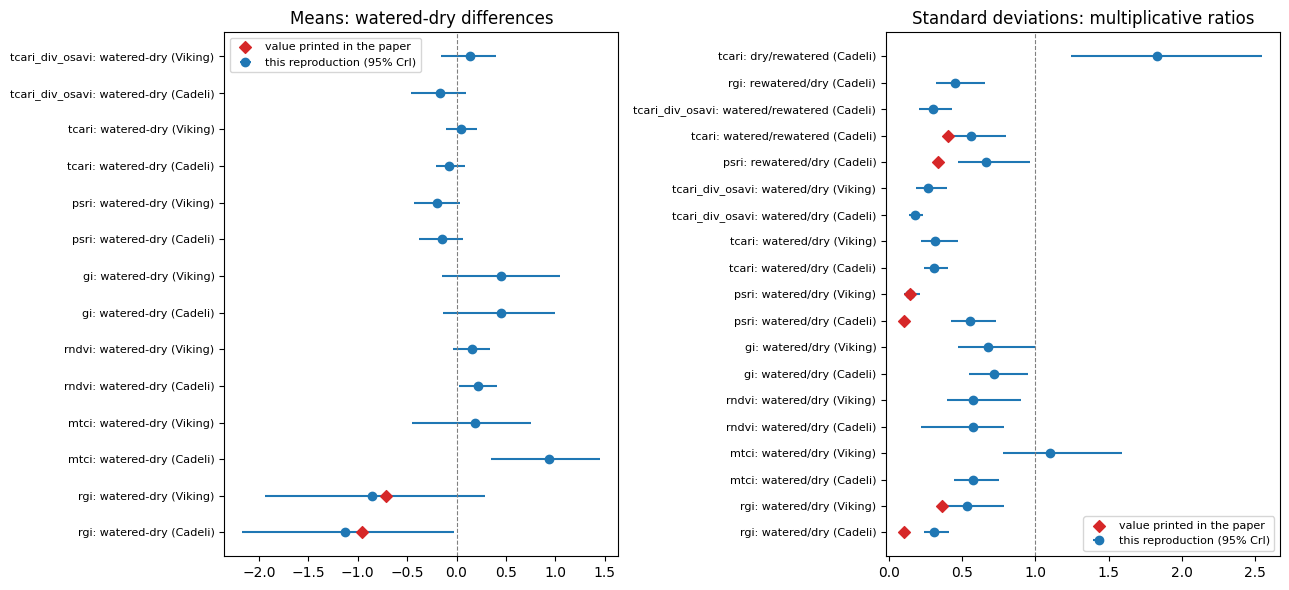

In [ ]:
plot_df = contrasts.merge(table[["dv", "parameter", "contrast", "paper_value", "paper_q2.5", "paper_q97.5"]],
                          on=["dv", "parameter", "contrast"])
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, par, ttl in [(axes[0], "mean", "Means: watered-dry differences"),
                     (axes[1], "sigma ratio", "Standard deviations: multiplicative ratios")]:
    sub = plot_df[plot_df.parameter == par].reset_index(drop=True)
    y = numpy.arange(len(sub))
    ax.errorbar(sub["median"], y, xerr=[sub["median"] - sub["q2.5"], sub["q97.5"] - sub["median"]],
                fmt="o", color="tab:blue", label="this reproduction (95% CrI)")
    has_paper = sub.paper_value.notna()
    ax.scatter(sub.loc[has_paper, "paper_value"], y[has_paper.values], marker="D", color="tab:red",
               zorder=3, label="value printed in the paper")
    ax.set_yticks(y, [f"{r.dv}: {r.contrast}" for r in sub.itertuples()], fontsize=8)
    ax.axvline(1 if par == "sigma ratio" else 0, color="grey", lw=0.8, ls="--")
    ax.set_title(ttl); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 10. Export

We save the contrast table as CSV inside the Colab VM (`/content/contrasts_vs_paper.csv`) so it can be downloaded from the Files pane.

（比較表を CSV として保存します。）

In [ ]:
out_path = "/content/contrasts_vs_paper.csv"
table.to_csv(out_path, index=False)
print("saved", out_path, len(table), "rows")

saved /content/contrasts_vs_paper.csv 33 rows


## 11. Interpretation and limitations

**What this reproduction shows (executed 2026-10-09, Colab CPU):**

- The **mean** treatment contrasts reproduce the paper closely: RGI is lower in watered plants (this run: ≈ −1.1 for 'Cadeli', ≈ −0.9 for 'Viking'; paper: −0.96 and −0.71), with wide credible intervals like in the paper; MTCI, RNDVI and GI show the positive water-availability influence reported in the Results.
- The **variability** contrasts reproduce the paper's direction — index standard deviations grow as the hydric regime worsens — but some magnitudes are attenuated relative to the printed values (e.g. RGI σ watered/dry for 'Cadeli' ≈ 0.3 vs paper 0.10), while others match well (PSRI 'Viking' ≈ 0.14). PSRI's rewatered/dry ratio for 'Cadeli' lands near the paper's 0.33.

**Why residual differences remain (all documented adaptations):** (1) the plant mask comes from *our* retrained SVM (CV accuracy ≈ 0.92 vs the authors' tuned model), not the deposited classified rasters; (2) the 6×6 grid sampler is deterministic whereas `raster::sampleRegular` picks its own cells; (3) the sampler is PyMC/NumPyro with fewer draws (4 × 1500) than brms (3 × 8000) — a few divergences may be reported and the σ ratios of small groups converge more slowly; (4) GROBID-extracted paper text was used for the quoted reference values.

**Not reproduced here:** SVM tuning via Bayesian optimization, the full-spectrum pre-processing/PCA analysis, the dry-fraction model, and the figures of the paper.

**本notebookの解釈と限界（JP）：** 平均の処理効果は論文とよく一致します。変動幅（σ）の効果は方向は一致しますが、マスクの再学習やサンプリング格子の違いにより、一部の指数で大きさが減衰します。SVM チューニング・フルスペクトル PCA・乾燥画素比率モデルは対象外です。

## 12. Provenance and references

- Paper: Żelazny & Lukáš 2020, Remote Sensing 12(20):3462, doi:10.3390/rs12203462 (full text obtained via OpenAlex work W3093954446; gold OA).
- Data & code: Zenodo record 3975431, v1.0.0 (2020-08-07), `zelazny2020drought.tar.gz`, MD5 `106127047f5613d7110230a984398639`, license GPL-2.0. Index formulas copied from `lib/5-vegind.R`; model structure from `lib/6-vegindlm.R`; pseudo-RGB mapping from `lib/pseudorgb.R`; grid size from `data/constants.R`.
- Hand labels: `data/pixels.csv` with pixel coordinates from `data/sampled_pixels-backup.csv`.
- The vegetation-index formulas, model structure, and priors in this notebook are quoted author code; the PyMC/SVM/grid-sampling glue is AI-generated for this Colab port.

**References:**
1. Żelazny, W. R.; Lukáš, J. Remote Sensing **2020**, 12, 3462.
2. Żelazny, W.; Lukáš, J. Data and code accompanying "Drought stress detection…". Zenodo, 2020, doi:10.5281/zenodo.3975431.
3. Bürkner, P.-C. *brms: An R Package for Bayesian Multilevel Models using Stan.* JSS **2017**, 80.
4. PhenoPaper investigation run p-d9dd30bad55e1f1258900ce0e831bf27-20261007T230930Z-448613 was used as prior research guidance; all facts above were re-verified from primary sources.